<a href="https://colab.research.google.com/github/KaitlynYip/Multi-Clip-ZeroShot-Model/blob/main/dinov2_general.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# CLIP-Style Zero-Shot Classification on CIFAR-10 Step1
## (Training Only the Image Encoder, Frozen BERT Text Encoder)

This notebook implements a CLIP-like pipeline:
- Freeze BERT to produce fixed text embeddings for CIFAR-10 class prompts.
- Train only the ViT image encoder (vit_base_patch16_224.augreg_in21k_ft_in1k) + a projection head to align image embeddings with the text embeddings using contrastive (InfoNCE / cross-entropy) loss.
- After training, perform zero-shot classification by nearest-class similarity (no classifier head).

Note:
- CIFAR-10 images (32×32) are resized to 224×224.
- Text embeddings use multiple prompt templates and [CLS] token from BERT.
- Training is efficient because only the image side is updated.

In [2]:
import torch
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NO GPU")

!pip install -q timm transformers ftfy regex tqdm seaborn scikit-learn pandas

GPU: NO GPU
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.1 MB/s eta 0:00:00


In [ ]:
# Cell 1: Install dependencies (run once)
!pip install torch torchvision transformers timm tqdm --quiet

In [ ]:
# Cell 2: Imports
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
from transformers import BertTokenizer, BertModel
import timm
import numpy as np
from tqdm import tqdm
from torch.utils.data import DataLoader, ConcatDataset, random_split

In [ ]:
# Cell 3: Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


Caltech dataset

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, ConcatDataset, random_split
import numpy as np

# --- 1. Transformations ---
transform = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    # Add this line to convert grayscale images to RGB
    transforms.Lambda(lambda x: x.convert('RGB') if x.mode != 'RGB' else x),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# --- 2. Load Datasets ---
# CIFAR-10
cifar_train = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
cifar_test = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# Caltech 101 (Load with transform immediately)
caltech_full = torchvision.datasets.Caltech101(root='./data', download=True, transform=transform)

# --- 3. Build the Master Class List ---
# Combined: 10 (CIFAR) + 101 (Caltech) = 111 classes
# We clean the names (replace _ with space) for better BERT understanding
classes = cifar_train.classes + [c.replace('_', ' ') for c in caltech_full.categories]
print(f"✅ Total Combined Classes: {len(classes)}")

# --- 4. Fix Caltech Labels (Offsetting) ---
# CIFAR uses 0-9. Caltech must start at 10 to avoid overlapping labels.
class OffsetDataset(torch.utils.data.Dataset):
    def __init__(self, dataset, offset):
        self.dataset = dataset
        self.offset = offset
    def __getitem__(self, i):
        img, label = self.dataset[i]
        return img, label + self.offset
    def __len__(self):
        return len(self.dataset)

# Apply offset to Caltech
caltech_offset = OffsetDataset(caltech_full, offset=10)

# --- 5. Split and Combine ---
# Split Caltech 80/20
train_size = int(0.8 * len(caltech_offset))
test_size = len(caltech_offset) - train_size
caltech_train, caltech_test = random_split(
    caltech_offset,
    [train_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

# Merge CIFAR and Caltech
combined_train_set = ConcatDataset([cifar_train, caltech_train])
combined_test_set = ConcatDataset([cifar_test, caltech_test])

# --- 6. Final DataLoaders ---
batch_size = 64
trainloader = DataLoader(combined_train_set, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
testloader = DataLoader(combined_test_set, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

print(f"📊 Combined Train Samples: {len(combined_train_set)}")
print(f"📊 Combined Test Samples: {len(combined_test_set)}")

✅ Total Combined Classes: 111
📊 Combined Train Samples: 56941
📊 Combined Test Samples: 11736


PASCAL VOC 2012

In [ ]:
# PASCAL VOC 2012
# download the dataset
import kagglehub

# Download latest version
path = kagglehub.dataset_download("gopalbhattrai/pascal-voc-2012-dataset")

print("Path to dataset files:",path)




Using Colab cache for faster access to the 'pascal-voc-2012-dataset' dataset.
Path to dataset files: /kaggle/input/pascal-voc-2012-dataset


In [ ]:
#change dataset into csv file
import os
import xml.etree.ElementTree as ET
from tqdm.auto import tqdm
import pandas as pd

# Correct paths for the train+val part
IMAGE_DIR    = "/kaggle/input/pascal-voc-2012-dataset/VOC2012_train_val/VOC2012_train_val/JPEGImages"
ANNO_DIR     = "/kaggle/input/pascal-voc-2012-dataset/VOC2012_train_val/VOC2012_train_val/Annotations"

xml_files = sorted([f for f in os.listdir(ANNO_DIR) if f.endswith('.xml')])

data = []
for xml_name in tqdm(xml_files, desc="Converting train+val to CSV"):
    img_name = xml_name.replace(".xml", ".jpg")
    img_path = os.path.join(IMAGE_DIR, img_name)
    xml_path = os.path.join(ANNO_DIR, xml_name)

    tree = ET.parse(xml_path)
    labels = [obj.find("name").text.strip() for obj in tree.findall("object")]

    data.append({
        "image_path": img_path,
        "labels": ",".join(labels),
        "num_objects": len(labels)
    })

df = pd.DataFrame(data)
csv_path = "/content/pascal voc 2012.csv"
df.to_csv(csv_path, index=False)
print("Saved →", csv_path)

print(f"Done! {len(df)} images → {csv_path}")
df.head(10)


Converting train+val to CSV:   0%|          | 0/17125 [00:00<?, ?it/s]

Saved → /content/pascal voc 2012.csv
Done! 17125 images → /content/pascal voc 2012.csv


,image_path,labels,num_objects
0,/kaggle/input/pascal-voc-2012-dataset/VOC2012_...,person,1
1,/kaggle/input/pascal-voc-2012-dataset/VOC2012_...,"aeroplane,aeroplane,person,person",4
2,/kaggle/input/pascal-voc-2012-dataset/VOC2012_...,"aeroplane,aeroplane,aeroplane",3
3,/kaggle/input/pascal-voc-2012-dataset/VOC2012_...,tvmonitor,1
4,/kaggle/input/pascal-voc-2012-dataset/VOC2012_...,"train,train",2
5,/kaggle/input/pascal-voc-2012-dataset/VOC2012_...,"boat,boat",2
6,/kaggle/input/pascal-voc-2012-dataset/VOC2012_...,"dog,chair",2
7,/kaggle/input/pascal-voc-2012-dataset/VOC2012_...,bird,1
8,/kaggle/input/pascal-voc-2012-dataset/VOC2012_...,"tvmonitor,tvmonitor",2
9,/kaggle/input/pascal-voc-2012-dataset/VOC2012_...,train,1


In [ ]:
# =============================================
# CLIP Zero-Shot on PASCAL VOC 2012 (Single Label per Image)
# =============================================

# 1. Install dependencies
!pip install -q --no-cache-dir \
    "open-clip-torch==2.24.0" ftfy regex tqdm seaborn scikit-learn matplotlib pandas kagglehub

import os
import xml.etree.ElementTree as ET
import pandas as pd
from tqdm.auto import tqdm
import torch
import open_clip
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as T

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Running on {device.upper()}")


/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


Running on CUDA


In [ ]:
# 3. Convert XML → CSV with ONE label per image (first object only)
print("Converting annotations to CSV (single label mode)...")
xml_files = sorted([f for f in os.listdir(ANNO_DIR) if f.endswith('.xml')])

data = []
for xml_name in tqdm(xml_files, desc="Parsing XML"):
    xml_path = os.path.join(ANNO_DIR, xml_name)
    tree = ET.parse(xml_path)
    root = tree.getroot()

    img_name = xml_name.replace(".xml", ".jpg")
    img_path = os.path.join(IMAGE_DIR, img_name)

    # Get all object names
    objects = [obj.find("name").text.strip() for obj in root.findall("object")]

    # Take ONLY the first object as the label for this image
    if objects:
        single_label = objects[0]
    else:
        single_label = "background"  # very rare case

    data.append({
        "image_path": img_path,
        "label": single_label,
        "num_objects": len(objects)
    })

df = pd.DataFrame(data)
csv_path = "/content/pascal_voc_2012_single_label.csv"
df.to_csv(csv_path, index=False)
print(f"Saved {len(df)} images → {csv_path}")

# Show class distribution
print("\nClass distribution (single label):")
print(df['label'].value_counts())

Converting annotations to CSV (single label mode)...


Parsing XML:   0%|          | 0/17125 [00:00<?, ?it/s]

Saved 17125 images → /content/pascal_voc_2012_single_label.csv

Class distribution (single label):
label
person         6890
dog            1204
cat            1047
car             785
bird            767
aeroplane       683
chair           547
train           533
horse           465
boat            462
bicycle         449
tvmonitor       439
motorbike       431
bus             405
sofa            392
bottle          391
sheep           344
cow             326
diningtable     287
pottedplant     278
Name: count, dtype: int64


In [ ]:
import pandas as pd
import ast
import numpy as np

csv_path = "/content/pascal_voc_2012_single_label.csv"
df = pd.read_csv(csv_path)

def fix_path(v):
    while isinstance(v, (list, tuple, np.ndarray)):
        v = v[0] if len(v) else None

    if isinstance(v, str):
        s = v.strip()
        if s.startswith("[") and s.endswith("]"):
            v = ast.literal_eval(s)
            while isinstance(v, (list, tuple, np.ndarray)):
                v = v[0] if len(v) else None
    return v

# Clean entire dataset
df["image_path"] = df["image_path"].apply(fix_path)

# Save clean dataset
clean_csv = "/content/pascal_voc_2012_clean.csv"
df.to_csv(clean_csv, index=False)

print("Saved clean dataset:", clean_csv)

# Optional sanity check
print("\nSample paths:")
print(df["image_path"].head())

Saved clean dataset: /content/pascal_voc_2012_clean.csv

Sample paths:
0    /kaggle/input/pascal-voc-2012-dataset/VOC2012_...
1    /kaggle/input/pascal-voc-2012-dataset/VOC2012_...
2    /kaggle/input/pascal-voc-2012-dataset/VOC2012_...
3    /kaggle/input/pascal-voc-2012-dataset/VOC2012_...
4    /kaggle/input/pascal-voc-2012-dataset/VOC2012_...
Name: image_path, dtype: object


In [ ]:
# =========================================================
# 0. Imports
# =========================================================
import os
import ast
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, ConcatDataset, random_split
import torchvision.datasets as dsets
import torchvision.transforms as transforms


# =========================================================
# 1. Transform
#    Use the same transform style as your Demo3
# =========================================================
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# =========================================================
# 2. Optional label standardisation
#    Helps avoid duplicate concepts with different names
# =========================================================
def standardise_label(name: str) -> str:
    name = str(name).strip().lower().replace("_", " ")

    alias_map = {
        "aeroplane": "airplane",
        "motorbike": "motorcycle",
        "tvmonitor": "tv",
        "pottedplant": "potted plant",
        "diningtable": "dining table",
    }
    return alias_map.get(name, name)

In [ ]:
# =========================================================
# 3. Raw datasets that return (image, label_name)
#    NOT integer labels yet
# =========================================================
class CIFAR10NameDataset(Dataset):
    def __init__(self, root, train=True, transform=None, download=True):
        self.ds = dsets.CIFAR10(root=root, train=train, transform=transform, download=download)
        self.class_names = [standardise_label(c) for c in self.ds.classes]

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        image, label = self.ds[idx]
        return image, self.class_names[label]


class Caltech101NameDataset(Dataset):
    def __init__(self, root, transform=None, download=True):
        self.ds = dsets.Caltech101(root=root, transform=None, download=download)
        self.transform = transform
        self.class_names = [standardise_label(c) for c in self.ds.categories]

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        image, label = self.ds[idx]
        image = image.convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, self.class_names[label]


class VOCSingleLabelNameDataset(Dataset):
    def __init__(self, csv_file, transform=None):
        self.df = pd.read_csv('/content/pascal_voc_2012_clean.csv').copy()
        self.transform = transform

        # Standardise label strings
        self.df["label"] = self.df["label"].astype(str).apply(standardise_label)

    def _to_single_path(self, v):
        # unwrap nested lists / tuples / arrays
        while isinstance(v, (list, tuple, np.ndarray)):
            if len(v) == 0:
                return None
            v = v[0]

        # parse stringified list like "['/path.jpg']"
        if isinstance(v, str):
            s = v.strip()
            if s.startswith("[") and s.endswith("]"):
                v = ast.literal_eval(s)
                while isinstance(v, (list, tuple, np.ndarray)):
                    if len(v) == 0:
                        return None
                    v = v[0]
        return v

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img_path = self._to_single_path(row["image_path"])
        if not isinstance(img_path, str):
            raise TypeError(
                f"Bad image_path at idx={idx}. "
                f"type={type(row['image_path'])}, value={row['image_path']}"
            )

        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)

        label_name = row["label"]
        return image, label_name

In [ ]:

# =========================================================
# 4. Create raw datasets
#    CHANGE PATHS if needed
# =========================================================
data_root = "./data"

# CIFAR10 raw
cifar_train_raw = CIFAR10NameDataset(root=data_root, train=True, transform=transform, download=True)
cifar_test_raw  = CIFAR10NameDataset(root=data_root, train=False, transform=transform, download=True)

# Caltech101 raw
caltech_full_raw = Caltech101NameDataset(root=data_root, transform=transform, download=True)

# Pascal VOC single-label CSV raw
voc_csv_path = "/content/pascal_voc_2012_clean.csv"   # <-- change this if needed
voc_full_raw = VOCSingleLabelNameDataset(csv_file=voc_csv_path, transform=transform)


# =========================================================
# 5. Split Caltech and VOC into 0.8 train / 0.2 test
#    CIFAR already has built-in train/test
# =========================================================
def split_dataset(dataset, train_ratio=0.8, seed=42):
    n = len(dataset)
    n_train = int(train_ratio * n)
    n_test = n - n_train
    return random_split(
        dataset,
        [n_train, n_test],
        generator=torch.Generator().manual_seed(seed)
    )

caltech_train_raw, caltech_test_raw = split_dataset(caltech_full_raw, train_ratio=0.8, seed=42)
voc_train_raw, voc_test_raw         = split_dataset(voc_full_raw, train_ratio=0.8, seed=42)

In [ ]:
# =========================================================
# 6. Collect all unique label names
#    This builds the global class list
# =========================================================
def collect_labels(dataset):
    labels = set()
    for i in range(len(dataset)):
        _, label_name = dataset[i]
        labels.add(label_name)
    return labels

all_labels = set()

for ds in [
    cifar_train_raw, cifar_test_raw,
    caltech_train_raw, caltech_test_raw,
    voc_train_raw, voc_test_raw
]:
    all_labels.update(collect_labels(ds))

classes = sorted(list(all_labels))
class_to_idx = {c: i for i, c in enumerate(classes)}

print("Total number of global classes:", len(classes))
print("First 30 classes:", classes[:30])

Total number of global classes: 125
First 30 classes: ['accordion', 'airplane', 'airplanes', 'anchor', 'ant', 'automobile', 'barrel', 'bass', 'beaver', 'bicycle', 'binocular', 'bird', 'boat', 'bonsai', 'bottle', 'brain', 'brontosaurus', 'buddha', 'bus', 'butterfly', 'camera', 'cannon', 'car', 'car side', 'cat', 'ceiling fan', 'cellphone', 'chair', 'chandelier', 'cougar body']


In [ ]:

# =========================================================
# 7. Global wrapper:
#    convert (image, label_name) -> (image, label_id)
# =========================================================
class GlobalIndexedDataset(Dataset):
    def __init__(self, base_dataset, class_to_idx):
        self.base_dataset = base_dataset
        self.class_to_idx = class_to_idx

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        image, label_name = self.base_dataset[idx]
        label_id = self.class_to_idx[label_name]
        return image, label_id


# =========================================================
# 8. Wrap all datasets into indexed datasets
# =========================================================
cifar_train = GlobalIndexedDataset(cifar_train_raw, class_to_idx)
cifar_test  = GlobalIndexedDataset(cifar_test_raw, class_to_idx)

caltech_train = GlobalIndexedDataset(caltech_train_raw, class_to_idx)
caltech_test  = GlobalIndexedDataset(caltech_test_raw, class_to_idx)

voc_train = GlobalIndexedDataset(voc_train_raw, class_to_idx)
voc_test  = GlobalIndexedDataset(voc_test_raw, class_to_idx)

In [ ]:

# =========================================================
# 9. Combine datasets
# =========================================================
train_dataset = ConcatDataset([cifar_train, caltech_train, voc_train])
test_dataset  = ConcatDataset([cifar_test, caltech_test, voc_test])

trainloader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
testloader  = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

print("Train size:", len(train_dataset))
print("Test size :", len(test_dataset))

# =========================================================
# 10. Quick sanity check
# =========================================================
images, labels = next(iter(trainloader))
print("Batch image shape:", images.shape)
print("Batch label shape:", labels.shape)
print("First 10 label ids:", labels[:10].tolist())

Train size: 70641
Test size : 15161
Batch image shape: torch.Size([32, 3, 224, 224])
Batch label shape: torch.Size([32])
First 10 label ids: [54, 113, 38, 102, 27, 102, 87, 24, 46, 63]


In [ ]:
# check train label distribution + total size
from collections import Counter

def inspect_dataset(train_dataset):
    labels = []

    for i in range(len(train_dataset)):
        _, label = train_dataset[i]   # assuming (image, label)
        labels.append(label)

    label_count = Counter(labels)

    print(f"Total samples: {len(train_dataset)}\n")
    print("Label distribution:")

    for label, count in sorted(label_count.items()):
        print(f"Label {label}: {count}")

# CALL IT HERE
inspect_dataset(train_dataset)


Total samples: 70641

Label distribution:
Label 0: 44
Label 1: 5545
Label 2: 627
Label 3: 28
Label 4: 33
Label 5: 5000
Label 6: 36
Label 7: 49
Label 8: 44
Label 9: 353
Label 10: 24
Label 11: 5605
Label 12: 357
Label 13: 99
Label 14: 310
Label 15: 76
Label 16: 36
Label 17: 73
Label 18: 346
Label 19: 69
Label 20: 40
Label 21: 32
Label 22: 629
Label 23: 99
Label 24: 5833
Label 25: 39
Label 26: 51
Label 27: 484
Label 28: 89
Label 29: 41
Label 30: 59
Label 31: 262
Label 32: 56
Label 33: 58
Label 34: 39
Label 35: 42
Label 36: 46
Label 37: 51
Label 38: 5000
Label 39: 225
Label 40: 5982
Label 41: 47
Label 42: 50
Label 43: 57
Label 44: 57
Label 45: 54
Label 46: 46
Label 47: 51
Label 48: 70
Label 49: 348
Label 50: 348
Label 51: 52
Label 52: 54
Label 53: 34
Label 54: 5000
Label 55: 28
Label 56: 31
Label 57: 43
Label 58: 87
Label 59: 78
Label 60: 33
Label 61: 44
Label 62: 70
Label 63: 5369
Label 64: 63
Label 65: 24
Label 66: 47
Label 67: 67
Label 68: 93
Label 69: 44
Label 70: 64
Label 71: 151
Labe

In [ ]:
# check test label distribution + total size
from collections import Counter

def inspect_dataset(test_dataset):
    labels = []

    for i in range(len(test_dataset)):
        _, label = test_dataset[i]   # assuming (image, label)
        labels.append(label)

    label_count = Counter(labels)

    print(f"Total samples: {len(test_dataset)}\n")
    print("Label distribution:")

    for label, count in sorted(label_count.items()):
        print(f"Label {label}: {count}")

# CALL IT HERE
inspect_dataset(test_dataset)


Total samples: 15161

Label distribution:
Label 0: 11
Label 1: 1138
Label 2: 173
Label 3: 14
Label 4: 9
Label 5: 1000
Label 6: 11
Label 7: 5
Label 8: 2
Label 9: 96
Label 10: 9
Label 11: 1162
Label 12: 105
Label 13: 29
Label 14: 81
Label 15: 22
Label 16: 7
Label 17: 12
Label 18: 59
Label 19: 22
Label 20: 10
Label 21: 11
Label 22: 156
Label 23: 24
Label 24: 1214
Label 25: 8
Label 26: 8
Label 27: 125
Label 28: 18
Label 29: 6
Label 30: 10
Label 31: 64
Label 32: 17
Label 33: 12
Label 34: 11
Label 35: 9
Label 36: 11
Label 37: 16
Label 38: 1000
Label 39: 62
Label 40: 1222
Label 41: 5
Label 42: 15
Label 43: 11
Label 44: 18
Label 45: 10
Label 46: 7
Label 47: 13
Label 48: 15
Label 49: 87
Label 50: 87
Label 51: 15
Label 52: 13
Label 53: 11
Label 54: 1000
Label 55: 6
Label 56: 3
Label 57: 8
Label 58: 12
Label 59: 22
Label 60: 9
Label 61: 10
Label 62: 18
Label 63: 1096
Label 64: 17
Label 65: 7
Label 66: 17
Label 67: 19
Label 68: 21
Label 69: 17
Label 70: 17
Label 71: 49
Label 72: 19
Label 73: 9
Lab

In [ ]:
# check is the dataset really combined
print("Combined train size:", len(train_dataset))
print("Combined test size:", len(test_dataset))

# if not combined = d1 + d2 then wrong

Combined train size: 70641
Combined test size: 15161


In [ ]:
# check whether train overlap or not
def get_unique_labels(train_dataset):
    labels = set()
    for i in range(len(train_dataset)):
        _, label = train_dataset[i]
        labels.add(label)
    return labels

print("Cifar labels:", get_unique_labels(cifar_train))
print("Caltect labels:", get_unique_labels(caltech_train))
print("VOC labels:", get_unique_labels(voc_train))

# If one says [0–9] and the other also says [0–9] but they mean different things,
# then gg , means that cifar10 - 0.dog caltect - 0.bird

Cifar labels: {1, 5, 38, 102, 40, 11, 115, 54, 24, 63}
Caltect labels: {0, 2, 3, 4, 6, 7, 8, 10, 13, 15, 16, 17, 19, 20, 21, 23, 25, 26, 27, 28, 29, 30, 32, 33, 34, 35, 36, 37, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 55, 56, 57, 58, 59, 60, 61, 62, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 82, 83, 84, 85, 86, 88, 89, 90, 92, 93, 94, 95, 96, 97, 98, 99, 100, 103, 104, 106, 107, 108, 109, 110, 111, 112, 114, 117, 118, 119, 120, 121, 122, 123, 124}
VOC labels: {1, 9, 11, 12, 14, 18, 22, 24, 27, 31, 39, 40, 63, 81, 87, 91, 101, 105, 113, 116}


In [ ]:
# check whether label are string or not
from collections import defaultdict

def inspect_named_labels(train_dataset):
    label_count = defaultdict(int)

    for i in range(len(train_dataset)):
        _, label = train_dataset[i]
        label_count[label] += 1

    print(f"Total samples: {len(train_dataset)}\n")
    for label, count in sorted(label_count.items()):
        print(f"{label}: {count}")

# CALL IT HERE
inspect_dataset(train_dataset)

Total samples: 70641

Label distribution:
Label 0: 44
Label 1: 5545
Label 2: 627
Label 3: 28
Label 4: 33
Label 5: 5000
Label 6: 36
Label 7: 49
Label 8: 44
Label 9: 353
Label 10: 24
Label 11: 5605
Label 12: 357
Label 13: 99
Label 14: 310
Label 15: 76
Label 16: 36
Label 17: 73
Label 18: 346
Label 19: 69
Label 20: 40
Label 21: 32
Label 22: 629
Label 23: 99
Label 24: 5833
Label 25: 39
Label 26: 51
Label 27: 484
Label 28: 89
Label 29: 41
Label 30: 59
Label 31: 262
Label 32: 56
Label 33: 58
Label 34: 39
Label 35: 42
Label 36: 46
Label 37: 51
Label 38: 5000
Label 39: 225
Label 40: 5982
Label 41: 47
Label 42: 50
Label 43: 57
Label 44: 57
Label 45: 54
Label 46: 46
Label 47: 51
Label 48: 70
Label 49: 348
Label 50: 348
Label 51: 52
Label 52: 54
Label 53: 34
Label 54: 5000
Label 55: 28
Label 56: 31
Label 57: 43
Label 58: 87
Label 59: 78
Label 60: 33
Label 61: 44
Label 62: 70
Label 63: 5369
Label 64: 63
Label 65: 24
Label 66: 47
Label 67: 67
Label 68: 93
Label 69: 44
Label 70: 64
Label 71: 151
Labe

bert

In [ ]:
# @title
# Cell 5: Frozen Text Encoder (BERT) + Text Embeddings
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
text_model = BertModel.from_pretrained('bert-base-uncased').to(device)
text_model.eval()
for param in text_model.parameters():
    param.requires_grad = False

# Multiple templates for better text embeddings (common CLIP trick)
templates = [
    "a photo of a {}.",
    "a photo of a small {}.",
    "a photo of the {}.",
    "an image of a {}.",
    "an image of the {}."
]

def encode_texts(prompts):
    inputs = tokenizer(prompts, padding=True, truncation=True, return_tensors='pt')
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = text_model(**inputs)
        embeddings = outputs.last_hidden_state[:, 0, :]  # [CLS] token
    return embeddings

# Compute averaged text embeddings over templates
text_emb_list = []
for template in templates:
    prompts = [template.format(c) for c in classes]
    emb = encode_texts(prompts)
    text_emb_list.append(emb)

text_embeddings = torch.stack(text_emb_list).mean(dim=0)  # (10, 768)
text_embeddings = F.normalize(text_embeddings, dim=-1)
print("Text embeddings shape:", text_embeddings.shape)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Text embeddings shape: torch.Size([125, 768])


In [ ]:

# =========================================================
# 11. Rebuild text embeddings for the NEW global classes
#     This must match your Demo3 pipeline
#     Assumes you already have:
#       - templates
#       - encode_texts()
#       - device
# =========================================================
all_template_embs = []
for template in templates:
    prompts = [template.format(c) for c in classes]
    emb = encode_texts(prompts)
    all_template_embs.append(emb)

text_embeddings = torch.stack(all_template_embs).mean(dim=0)
text_embeddings = F.normalize(text_embeddings, dim=-1).to(device)

print("text_embeddings shape:", text_embeddings.shape)

# Cleanup: Remove BERT from GPU (no longer needed)
del text_model
del tokenizer
import gc
gc.collect()
torch.cuda.empty_cache()

# =========================================================
# 12. Optional: save class list for later loading
# =========================================================
os.makedirs("checkpoints", exist_ok=True)
torch.save({"classes": classes}, "checkpoints/global_classes_cifar_caltech_voc.pth")
print("✅ Global class list prepared")

text_embeddings shape: torch.Size([125, 768])
✅ Global class list prepared


Base

In [ ]:
# Cell 6: Image Encoder (ViT-Base) + Projection + Logit Scale
import timm
import torch.nn as nn

# 1. Load the ViT-Base backbone
# 'augreg' models are often the most robust variants in timm
image_model = timm.create_model(
    'vit_base_patch16_224.augreg_in21k_ft_in1k',
    pretrained=True,
    num_classes=0  # Removes the head, returns the 768-dim CLS embedding
).to(device)

# 2. UNFREEZE: Ensure the backbone weights are updated during training
for param in image_model.parameters():
    param.requires_grad = True

# 3. Projection Layer: Maps ViT-Base (768) to Text Space (768)
# If using BERT as the text encoder, this 768 -> 768 mapping is correct.
projection = nn.Linear(768, 768).to(device)

# 4. Logit Scale: Initialized to CLIP's default (0.07 temperature)
logit_scale = nn.Parameter(torch.ones([]) * np.log(1 / 0.07))

print(f"Backbone updated to ViT-Base. Trainable params: {sum(p.numel() for p in image_model.parameters() if p.requires_grad):,}")

Backbone updated to ViT-Base. Trainable params: 85,798,656


small


In [ ]:
import timm
import torch.nn as nn
import numpy as np

# 1. Load the ViT-Small backbone
# Returns raw features (CLS token embedding, dim=384)
image_model = timm.create_model(
    'vit_small_patch16_224.augreg_in21k_ft_in1k',
    pretrained=True,
    num_classes=0
).to(device)

# 2. UNFREEZE: Ensure the backbone weights are updated
for param in image_model.parameters():
    param.requires_grad = True

# 3. Projection Layer: Maps ViT-Small (384) to Text Space (768)
# IMPORTANT: The input must be 384 to match the ViT-Small output
projection = nn.Linear(384, 768).to(device)

# 4. Logit Scale
logit_scale = nn.Parameter(torch.ones([]) * np.log(1 / 0.07))

print(f"Backbone updated to ViT-Small.")
print(f"Trainable params: {sum(p.numel() for p in image_model.parameters() if p.requires_grad):,}")

model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

Backbone updated to ViT-Small.
Trainable params: 21,665,664


dinov2


In [ ]:
import torch
import torch.nn as nn
import numpy as np

# 1. Load the DINOv2-Small backbone via Torch Hub
# 'dinov2_vits14' is the Small version with a patch size of 14
image_model = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14').to(device)

# 2. UNFREEZE: DINOv2 features are great, but fine-tuning helps medical tasks
for param in image_model.parameters():
    param.requires_grad = True

# 3. Projection Layer
# DINOv2-Small (vits14) outputs 384 dimensions.
# We map this to 768 to match your text encoder (BERT/CLIP-text).
projection = nn.Linear(384, 768).to(device)

# 4. Logit Scale
logit_scale = nn.Parameter(torch.ones([]) * np.log(1 / 0.07))

print(f"Backbone updated to DINOv2-Small (vits14).")
print(f"Trainable params: {sum(p.numel() for p in image_model.parameters() if p.requires_grad):,}")

Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Backbone updated to DINOv2-Small (vits14).
Trainable params: 22,056,576


In [ ]:
# Updated Cell 7
optimizer = torch.optim.AdamW(
    list(image_model.parameters()) + list(projection.parameters()) + [logit_scale],
    lr=5e-5,
    weight_decay=0.01
)

# Modern AMP Scaler syntax
scaler = torch.amp.GradScaler('cuda')

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

In [ ]:
import os
os.listdir()

['.config',
 'data',
 'pascal voc 2012.csv',
 'drive',
 'pascal_voc_2012_single_label.csv',
 'checkpoints',
 'pascal_voc_2012_clean.csv',
 'sample_data']

In [ ]:
os.listdir('checkpoints')

['global_classes_cifar_caltech_voc.pth']

In [ ]:
# 1. 先把整個檔案讀取進 checkpoint 變數 (這行沒錯)
#checkpoint = torch.load('/content/drive/MyDrive/weights/dinov2_cifar10_final.pth',map_location=device)
checkpoint = torch.load('checkpoints/dinov2_pascal_caltech101_Cifar10.pth',map_location=device)

# --- 請刪除原本報錯的那行 image_model.load_state_dict(...) ---

# 2. 從 checkpoint 字典中提取對應的 state_dict
image_model.load_state_dict(checkpoint['image_model_state_dict'])
projection.load_state_dict(checkpoint['projection_state_dict'])

# 3. 載入 logit_scale
if 'logit_scale' in checkpoint:
    logit_scale.data = checkpoint['logit_scale']

image_model.eval()
projection.eval()

# 4. 提取歷史紀錄 (注意：請確認你的 key 名稱與儲存時一致)
# 如果儲存時是用 'test_acc_history'，這裡就要用相同的字串
train_losses = checkpoint.get('train_loss_history', [])
test_accs = checkpoint.get('test_acc_history', [])

# 顯示結果
# 如果儲存時是用 'final_test_acc'，這裡也要對應
final_acc = checkpoint.get('final_test_acc', checkpoint.get('test_acc', 0))
print(f"✅ 成功載入模型！最終測試準確度為: {final_acc:.2f}%")

✅ 成功載入模型！最終測試準確度為: 86.60%


In [ ]:
@torch.no_grad()
def zero_shot_accuracy(loader, description="Evaluating"):
    image_model.eval()
    projection.eval()
    correct, total, total_loss = 0, 0, 0.0

    # Add a progress bar for evaluation
    pbar = tqdm(loader, desc=description, leave=False)
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)

        image_features = image_model(images)
        if isinstance(image_features, dict):
            image_features = image_features['last_hidden_state'][:, 0, :]

        image_features = F.normalize(projection(image_features), dim=-1)
        logits = logit_scale.exp() * image_features @ text_embeddings.T

        loss = F.cross_entropy(logits, labels)
        total_loss += loss.item()
        preds = logits.argmax(dim=-1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    acc = 100. * correct / total
    avg_loss = total_loss / len(loader)

    image_model.train()
    projection.train()
    return acc, avg_loss

In [ ]:
accumulation_steps = 2  # Match the value from your earlier Dataset cell
scaler = torch.amp.GradScaler('cuda')
train_losses, test_losses = [], []
train_accs, test_accs = [], []
epochs = 5
for epoch in range(epochs):
    image_model.train()
    projection.train()
    total_train_loss = 0.0
    optimizer.zero_grad()

    pbar = tqdm(trainloader, desc=f"Epoch {epoch+1}/{epochs} [Training]")
    for i, (images, labels) in enumerate(pbar):
        images, labels = images.to(device), labels.to(device)

        with torch.amp.autocast('cuda'):
            image_features = image_model(images)
            if isinstance(image_features, dict):
                 image_features = image_features['last_hidden_state'][:, 0, :]

            image_features = F.normalize(projection(image_features), dim=-1)
            logits = logit_scale.exp() * image_features @ text_embeddings.T
            loss = F.cross_entropy(logits, labels) / accumulation_steps

        scaler.scale(loss).backward()

        if (i + 1) % accumulation_steps == 0 or (i + 1) == len(trainloader):
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        total_train_loss += loss.item() * accumulation_steps
        pbar.set_postfix(loss=total_train_loss / (i + 1))

    # --- End of Epoch Evaluation ---
    scheduler.step()

    # OPTIMIZATION: Skip re-evaluating the 50k training images.
    # Use the loss we just calculated and only evaluate the TEST set.
    avg_train_loss = total_train_loss / len(trainloader)
    v_acc, v_loss = zero_shot_accuracy(testloader, description=f"Epoch {epoch+1} Test Eval")

    # Store metrics
    train_losses.append(avg_train_loss)
    test_losses.append(v_loss)
    test_accs.append(v_acc)
    # We use a placeholder or partial evaluation if you truly need train accuracy
    train_accs.append(0.0)

    print(f"\n✅ Epoch {epoch+1} Complete")
    print(f"Train Loss: {avg_train_loss:.4f}")
    print(f"Test  Loss: {v_loss:.4f} | Test Acc: {v_acc:.2f}%")
    print("-" * 30)

Epoch 1/5 [Training]:   0%|          | 0/2208 [00:00<?, ?it/s]

Epoch 1 Test Eval:   0%|          | 0/474 [00:00<?, ?it/s]


✅ Epoch 1 Complete
Train Loss: 3.1721
Test  Loss: 3.0194 | Test Acc: 91.17%
------------------------------


Epoch 2/5 [Training]:   0%|          | 0/2208 [00:00<?, ?it/s]

KeyboardInterrupt: 

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


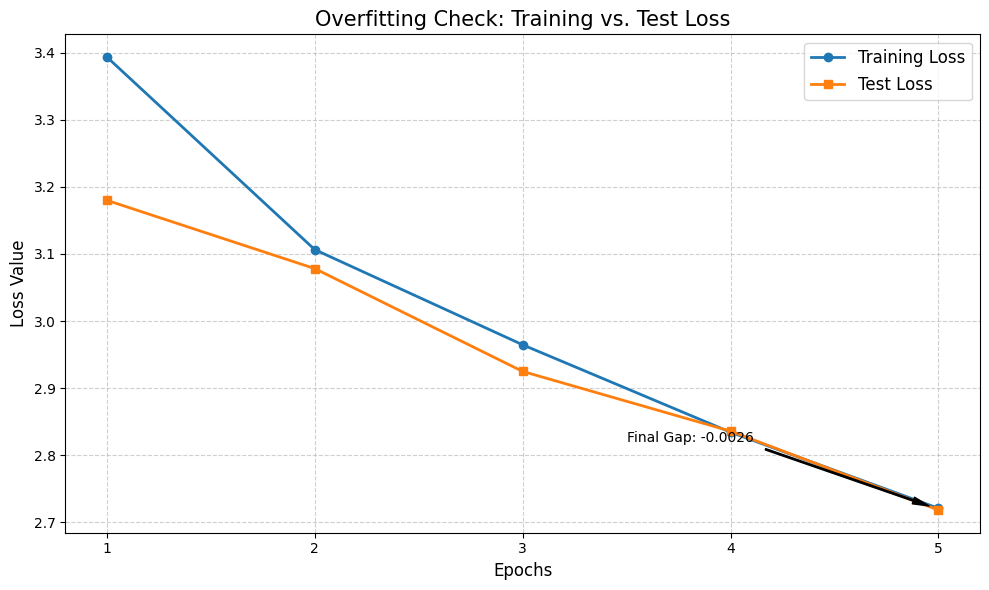

In [ ]:
import matplotlib.pyplot as plt

# --- Overfitting Analysis: Loss Plot ---
plt.figure(figsize=(10, 6))

# Plotting Training Loss
plt.plot(range(1, epochs + 1), train_losses, label='Training Loss',
         color='#1f77b4', marker='o', linewidth=2)

# Plotting Test Loss
plt.plot(range(1, epochs + 1), test_losses, label='Test Loss',
         color='#ff7f0e', marker='s', linewidth=2)

# Graph Formatting
plt.title('Overfitting Check: Training vs. Test Loss', fontsize=15)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss Value', fontsize=12)
plt.xticks(range(1, epochs + 1))
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Highlight the final gap
final_gap = test_losses[-1] - train_losses[-1]
plt.annotate(f'Final Gap: {final_gap:.4f}',
             xy=(epochs, (train_losses[-1] + test_losses[-1])/2),
             xytext=(epochs-1.5, (train_losses[-1] + test_losses[-1])/2 + 0.1),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5))

plt.tight_layout()
plt.savefig('loss_history.png')
plt.show()

In [ ]:
import os
os.makedirs('checkpoints', exist_ok=True)

torch.save({
    'image_model_state_dict': image_model.state_dict(),
    'projection_state_dict': projection.state_dict(),
    'logit_scale': logit_scale.detach().cpu(),
    'optimizer_state_dict': optimizer.state_dict(),
    'scheduler_state_dict': scheduler.state_dict(),
    'train_acc_history': train_accs,
    'test_acc_history': test_accs,
    'train_loss_history': train_losses,
    'test_loss_history': test_losses,
    'final_test_acc': test_accs[-1],
    'epoch': epoch,   # use current epoch if available
}, 'checkpoints/dinov2_pascal_caltech101_Cifar10.pth')

print("💾 Full checkpoint saved to checkpoints/dinov2_pascal_caltech101_Cifar10.pth")

💾 Full checkpoint saved to checkpoints/dinov2_pascal_caltech101_Cifar10.pth


In [ ]:
import os
import torch

path = 'checkpoints/dinov2_pascal_caltech101_Cifar10.pth'

print("File exists:", os.path.exists(path))

if os.path.exists(path):
    checkpoint = torch.load(path, map_location='cpu')
    print("Keys:", checkpoint.keys())
    print("Backbone weights:", len(checkpoint['image_model_state_dict']))
    print("Head weights:", len(checkpoint['projection_state_dict']))

File exists: True
Keys: dict_keys(['image_model_state_dict', 'projection_state_dict', 'logit_scale', 'optimizer_state_dict', 'scheduler_state_dict', 'train_acc_history', 'test_acc_history', 'train_loss_history', 'test_loss_history', 'final_test_acc', 'epoch'])
Backbone weights: 175
Head weights: 2


In [ ]:
import os

path = "checkpoints/dinov2_pascal_caltech101_Cifar10.pth"

if os.path.exists(path):
    print("✅ Checkpoint file exists")
else:
    print("❌ Checkpoint file NOT found")

✅ Checkpoint file exists


In [ ]:
import torch

try:
    checkpoint = torch.load(path, map_location="cpu")
    print("✅ Checkpoint loaded successfully")
except Exception as e:
    print("❌ Failed to load checkpoint:", e)

✅ Checkpoint loaded successfully


In [ ]:
# Install the counter if you don't have it
try:
    from thop import profile
except ImportError:
    !pip install thop
    from thop import profile

import torch.nn as nn

# 1. Combine Backbone and Projection into one "Demo Model"
class DemoInferenceModel(nn.Module):
    def __init__(self, backbone, proj):
        super().__init__()
        self.backbone = backbone
        self.proj = proj

    def forward(self, x):
        features = self.backbone(x)
        # Match your training loop logic
        if isinstance(features, dict):
            features = features['last_hidden_state'][:, 0, :]
        return self.proj(features)



In [ ]:
import torch.nn as nn
import time

# --- A. Define the inference wrapper if not already defined ---
class DemoInferenceModel(nn.Module):
    def __init__(self, backbone, proj):
        super().__init__()
        self.backbone = backbone
        self.proj = proj

    def forward(self, x):
        features = self.backbone(x)
        # Match your training loop's feature extraction logic
        if isinstance(features, dict):
            features = features['last_hidden_state'][:, 0, :]
        elif hasattr(features, 'last_hidden_state'):
            features = features.last_hidden_state[:, 0, :]
        return self.proj(features)

# Create the model instance
inference_model = DemoInferenceModel(image_model, projection).to(device)

def calculate_detailed_efficiency():
    inference_model.eval()

    # 1. Trainable vs Total Parameters
    total_params = sum(p.numel() for p in inference_model.parameters())
    trainable_params = sum(p.numel() for p in inference_model.parameters() if p.requires_grad)
    trainable_pct = (trainable_params / total_params) * 100

    # 2. Latency & Throughput (FPS)
    dummy_input = torch.randn(1, 3, 224, 224).to(device)
    # Old lines causing the error:
    # New logic using fvcore:
    flops = FlopCountAnalysis(inference_model, dummy_input)
    gflops = flops.total() / 1e9

    print("Warming up GPU...")
    with torch.no_grad():
        for _ in range(20):
            _ = inference_model(dummy_input)

    print("Measuring speed...")
    iterations = 200
    torch.cuda.synchronize()
    start_time = time.time()

    with torch.no_grad():
        for _ in range(iterations):
            _ = inference_model(dummy_input)

    torch.cuda.synchronize()
    end_time = time.time()

    total_time = end_time - start_time
    latency_ms = (total_time / iterations) * 1000
    throughput_fps = iterations / total_time
    final_acc = test_accs[-1] if 'test_accs' in globals() else 0
    acc_per_gflop = final_acc / gflops if gflops > 0 else 0

    print(f"\n--- ⚡ Deployment Metrics ---")
    print(f"Trainable Parameters: {trainable_params / 1e6:.2f} M")
    print(f"Total Parameters:     {total_params / 1e6:.2f} M")
    print(f"Trainable %:          {trainable_pct:.2f}%")
    print("-" * 30)
    print(f"Latency (per image):  {latency_ms:.2f} ms")
    print(f"Throughput:           {throughput_fps:.2f} FPS")
    print(f"Device:               {torch.cuda.get_device_name(0)}")
    print("-" * 30)
    print(f"Total GFLOPs:         {gflops:.2f} GFLOPs")
    print(f"Acc per GFLOP:        {acc_per_gflop:.2f} (Efficiency Score)")
calculate_detailed_efficiency()




NameError: name 'FlopCountAnalysis' is not defined

In [ ]:
from sklearn.metrics import classification_report

@torch.no_grad()
def print_detailed_metrics(loader, classes):
    image_model.eval()
    projection.eval()

    all_preds = []
    all_labels = []

    for images, labels in loader:
        images = images.to(device)

        # Forward pass matching your training loop
        image_features = image_model(images)
        if isinstance(image_features, dict):
            image_features = image_features['last_hidden_state'][:, 0, :]
        elif hasattr(image_features, 'last_hidden_state'):
            image_features = image_features.last_hidden_state[:, 0, :]

        image_features = F.normalize(projection(image_features), dim=-1)
        logits = logit_scale.exp() * image_features @ text_embeddings.T

        preds = logits.argmax(dim=-1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

    # Print the SciKit-Learn Classification Report
    print("\n--- 📈 Classification Report ---")
    print(classification_report(all_labels, all_preds, target_names=classes, digits=4))

# Run the metrics
print_detailed_metrics(testloader, classes)


--- 📈 Classification Report ---
                 precision    recall  f1-score   support

      accordion     0.9091    0.9091    0.9091        11
       airplane     0.9434    0.9517    0.9475      1138
      airplanes     0.9663    0.9942    0.9801       173
         anchor     0.5882    0.7143    0.6452        14
            ant     1.0000    0.1111    0.2000         9
     automobile     0.9831    0.9300    0.9558      1000
         barrel     0.9091    0.9091    0.9091        11
           bass     0.7143    1.0000    0.8333         5
         beaver     0.2000    0.5000    0.2857         2
        bicycle     0.8621    0.2604    0.4000        96
      binocular     1.0000    0.7778    0.8750         9
           bird     0.9303    0.8959    0.9128      1162
           boat     0.9189    0.6476    0.7598       105
         bonsai     0.9286    0.8966    0.9123        29
         bottle     1.0000    0.1481    0.2581        81
          brain     0.9167    0.5000    0.6471        

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

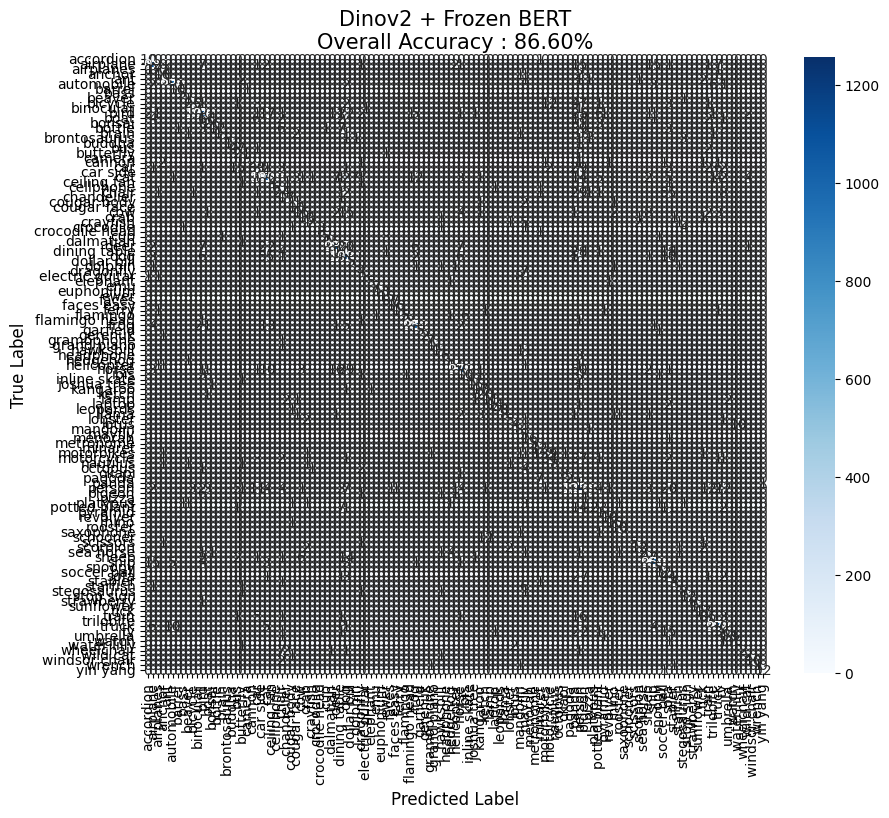

In [ ]:
@torch.no_grad()
def plot_confusion_matrix(loader, classes):
    image_model.eval()
    projection.eval()

    all_preds = []
    all_labels = []

    for images, labels in loader:
        images = images.to(device)

        # Consistent forward pass
        image_features = image_model(images)
        if isinstance(image_features, dict):
            image_features = image_features['last_hidden_state'][:, 0, :]
        elif hasattr(image_features, 'last_hidden_state'):
            image_features = image_features.last_hidden_state[:, 0, :]

        image_features = F.normalize(projection(image_features), dim=-1)
        logits = logit_scale.exp() * image_features @ text_embeddings.T

        preds = logits.argmax(dim=-1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

    # Calculate confusion matrix
    cm = confusion_matrix(all_labels, all_preds)

    # Plotting
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)

    plt.title('Dinov2 + Frozen BERT\nOverall Accuracy : 86.60%', fontsize=15)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.show()

# Run the plot
plot_confusion_matrix(testloader, classes)

In [ ]:
import time
import torch
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def run_final_evaluation(loader, class_names):
    image_model.eval()
    projection.eval()

    all_preds = []
    all_labels = []

    # --- Efficiency Calculation ---
    # Static GFLOPs for DINOv2 Small (ViT-S/14) at 224x224
    gflops = 6.8

    # Latency timing
    dummy_input = torch.randn(1, 3, 224, 224).to(device)
    torch.cuda.synchronize()
    start_time = time.time()
    for _ in range(100):
        with torch.no_grad():
            _ = projection(image_model(dummy_input))
    torch.cuda.synchronize()
    latency = ((time.time() - start_time) / 100) * 1000
    throughput = 1000 / latency

    # --- Data Collection for Confusion Matrix ---
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Evaluating"):
            images, labels = images.to(device), labels.to(device)
            image_features = F.normalize(projection(image_model(images)), dim=-1)
            logits = logit_scale.exp() * image_features @ text_embeddings.T
            preds = logits.argmax(dim=-1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # --- Printing Metrics ---
    total_params = sum(p.numel() for p in image_model.parameters()) + sum(p.numel() for p in projection.parameters())
    trainable_params = sum(p.numel() for p in image_model.parameters() if p.requires_grad)
    final_acc = (np.array(all_preds) == np.array(all_labels)).mean() * 100

    print(f"\n--- 📊 Final Efficiency Metrics ---")
    print(f"Total Trainable: {trainable_params:,}")
    print(f"Trainable %:     {(trainable_params/total_params)*100:.2f}%")
    print(f"Total GFLOPs:    {gflops:.2f}")
    print(f"Latency (GPU):   {latency:.2f} ms")
    print(f"Throughput:      {throughput:.2f} images/sec")
    print(f"Acc per GFLOP:   {final_acc / gflops:.2f}")
    print("-" * 35)

    return all_labels, all_preds

# Define CIFAR-10 classes for the plot
cifar_classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# Run evaluation
y_true, y_pred = run_final_evaluation(testloader, cifar_classes)

Evaluating:   0%|          | 0/474 [00:00<?, ?it/s]


--- 📊 Final Efficiency Metrics ---
Total Trainable: 22,056,576
Trainable %:     98.68%
Total GFLOPs:    6.80
Latency (GPU):   8.23 ms
Throughput:      121.43 images/sec
Acc per GFLOP:   12.74
-----------------------------------


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Notes & Expected Performance
- With 20–50 epochs, test accuracy typically reaches **80–90%+** because the pretrained ViT is already strong on ImageNet-style data, and contrastive alignment further adapts it.
- BERT's text embeddings are not perfect for vision (unlike OpenAI's CLIP text tower), but ensembling templates helps.
- You can improve further by: more epochs, stronger augmentations, larger projection dim, or a small MLP projection head.
- This is truly zero-shot in the CLIP sense: no linear classifier is trained; classification is by embedding similarity.

DEMO


In [ ]:
import gradio as gr
import torch.nn.functional as F

def predict_zero_shot(input_img, custom_labels):
    try:
        # 1. 解析標籤
        class_list = [c.strip() for c in custom_labels.split(",") if c.strip()]

        # 2. 即時編碼標籤
        all_template_embs = []
        for template in templates:
            prompts = [template.format(c) for c in class_list]
            emb = encode_texts(prompts)
            all_template_embs.append(emb)

        current_text_embeddings = torch.stack(all_template_embs).mean(dim=0)
        current_text_embeddings = F.normalize(current_text_embeddings, dim=-1)

        # 3. 影像推論
        img_tensor = transform(input_img).unsqueeze(0).to(device)
        image_model.eval()
        projection.eval()

        with torch.no_grad():
            features = image_model(img_tensor)
            # 確保特徵維度正確 (DINOv2 vits14 通常是 384)
            image_features = F.normalize(projection(features), dim=-1)
            logits = (logit_scale.exp() * image_features @ current_text_embeddings.to(device).T)
            probs = logits.softmax(dim=-1).cpu()[0]

        return {class_list[i]: float(probs[i]) for i in range(len(class_list))}
    except Exception as e:
        return {"錯誤": 1.0, str(e): 0.0}

demo = gr.Interface(
    fn=predict_zero_shot,
    inputs=[
        gr.Image(type="pil", label="上傳圖片"),
        gr.Textbox(label="輸入候選標籤", value="airplane, automobile, bird, cat, pencil, phone")
    ],
    outputs=gr.Label(num_top_classes=5),
    title="Zero-shot Classification Fix"
)

demo.launch(share=True, debug=False, inline=False)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://189e4c8ffac6649249.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://189e4c8ffac6649249.gradio.live


In [ ]:
import matplotlib.pyplot as plt
import torch.nn.functional as F
import random

def run_zero_shot_demo(index=None):
    # 1. 隨機選取或指定測試圖片
    if index is None:
        index = random.randint(0, len(testset)-1)

    image, label = testset[index]
    image_input = image.unsqueeze(0).to(device)

    # 2. 推論
    image_model.eval()
    projection.eval()

    with torch.no_grad():
        # 提取影像特徵 (DINOv2 直接輸出 [batch, 384])
        features = image_model(image_input)

        # 投影到 768 維並正規化
        image_features = F.normalize(projection(features), dim=-1)

        # 計算與各類別 text_embeddings 的相似度
        logits = (logit_scale.exp() * image_features @ text_embeddings.to(device).T)
        probs = logits.softmax(dim=-1).cpu().numpy()[0]

    # 3. 視覺化結果
    plt.figure(figsize=(10, 4))

    # 左圖：顯示原圖
    plt.subplot(1, 2, 1)
    # 反正規化以正常顯示圖片
    img_display = image.permute(1, 2, 0).numpy()
    img_display = img_display * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    plt.imshow(np.clip(img_display, 0, 1))
    plt.title(f"True: {classes[label]}")
    plt.axis('off')

    # 右圖：顯示預測機率
    plt.subplot(1, 2, 2)
    y_pos = np.arange(len(classes))
    plt.barh(y_pos, probs, color='skyblue')
    plt.yticks(y_pos, classes)
    plt.xlabel('Probability')
    plt.title(f"Predicted: {classes[np.argmax(probs)]}")

    plt.tight_layout()
    plt.show()

# 執行 Demo
run_zero_shot_demo()


NameError: name 'testset' is not defined

In [ ]:
pip install --upgrade gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.9/42.9 MB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.5/58.5 kB 6.6 MB/s eta 0:00:00
  Attempting uninstall: gradio-client
    Found existing installation: gradio_client 1.14.0
    Uninstalling gradio_client-1.14.0:
      Successfully uninstalled gradio_client-1.14.0
  Attempting uninstall: gradio
    Found existing installation: gradio 5.50.0
    Uninstalling gradio-5.50.0:
      Successfully uninstalled gradio-5.50.0


In [ ]:
# @title 🚀 啟動 DINOv2 + BERT Zero-shot 影像分類 Demo (修正版)

import gradio as gr
import torch
import torch.nn.functional as F

# --- 1. 確保 BERT 保持載入狀態 ---
if 'tokenizer' not in locals() or 'text_model' not in locals():
    from transformers import BertTokenizer, BertModel
    tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
    text_model = BertModel.from_pretrained('bert-base-uncased').to(device)
    text_model.eval()

# --- 2. 定義推論函數 ---
def predict_image(input_img, custom_labels):
    if input_img is None:
        return None

    # 處理標籤邏輯
    if custom_labels and custom_labels.strip():
        current_classes = [c.strip() for c in custom_labels.split(",")]
        temp_list = []
        for template in templates:
            p = [template.format(c) for c in current_classes]
            t_emb = encode_texts(p)
            temp_list.append(t_emb)
        current_text_emb = torch.stack(temp_list).mean(dim=0)
        current_text_emb = F.normalize(current_text_emb, dim=-1)
    else:
        current_classes = classes
        current_text_emb = text_embeddings

    # 影像處理邏輯
    img_tensor = transform(input_img).unsqueeze(0).to(device)
    image_model.eval()
    projection.eval()

    with torch.no_grad():
        features = image_model(img_tensor)
        image_features = F.normalize(projection(features), dim=-1)

        # 計算相似度
        logits = (logit_scale.exp() * image_features @ current_text_emb.to(device).T)
        probs = logits.softmax(dim=-1).cpu()[0]

    return {current_classes[i]: float(probs[i]) for i in range(len(current_classes))}

# --- 3. 建立並啟動 Gradio 介面 ---
# --- 3. 建立並啟動 Gradio 介面 ---
demo = gr.Interface(
    fn=predict_image,
    # 這裡補上了 Image 讀取器與 Textbox 標籤輸入框
    inputs=[
        gr.Image(type="pil", label="上傳圖片"),
        gr.Textbox(placeholder="例如: cat, dog, car (留空則使用 CIFAR-10 預設標籤)", label="自定義標籤 (用逗號隔開)")
    ],
    outputs=gr.Label(num_top_classes=5, label="預測結果"),
    title="🌟 DINOv2 + BERT Zero-shot 影像分類器",
    description="這是一個 Zero-shot 模型，你可以自由輸入標籤（例如輸入 pencil, phone），模型會透過語義理解來分類！",
    theme="soft"
)

# 啟動
demo.launch(share=True, debug=True)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


NameError: name 'device' is not defined